## Implementing TF-IDF from scratch not using any libraries.

In [62]:
with open("data/mixed_topic_corpus.txt") as f:
    corpus = f.read()
    
corpus

'Machine learning models analyze data to identify patterns and improve predictions.\n\nNeural networks learn complex representations from large datasets.\n\nNatural language processing helps computers understand human language.\n\nDeep learning techniques power many modern computer vision systems.\n\nInformation retrieval systems rank documents according to relevance.\n\nDoctors analyze blood biomarkers to detect early signs of disease.\n\nMedical researchers study how genetics influence chronic illness.\n\nClinical trials evaluate the safety and effectiveness of new treatments.\n\nRadiology imaging helps physicians diagnose internal conditions.\n\nPreventive medicine focuses on reducing risk factors for disease.\n\nFinancial analysts evaluate market trends to guide investment decisions.\n\nStock markets react quickly to economic news and global events.\n\nPortfolio diversification helps reduce financial risk.\n\nInterest rates influence borrowing costs and economic growth.\n\nRisk man

In [63]:
# Splitting on basis of sentence boundary ('.')
documents = corpus.split(".")
documents

['Machine learning models analyze data to identify patterns and improve predictions',
 '\n\nNeural networks learn complex representations from large datasets',
 '\n\nNatural language processing helps computers understand human language',
 '\n\nDeep learning techniques power many modern computer vision systems',
 '\n\nInformation retrieval systems rank documents according to relevance',
 '\n\nDoctors analyze blood biomarkers to detect early signs of disease',
 '\n\nMedical researchers study how genetics influence chronic illness',
 '\n\nClinical trials evaluate the safety and effectiveness of new treatments',
 '\n\nRadiology imaging helps physicians diagnose internal conditions',
 '\n\nPreventive medicine focuses on reducing risk factors for disease',
 '\n\nFinancial analysts evaluate market trends to guide investment decisions',
 '\n\nStock markets react quickly to economic news and global events',
 '\n\nPortfolio diversification helps reduce financial risk',
 '\n\nInterest rates influ

In [64]:
# Cleaning the documents

# remove empty document
documents = [doc for doc in documents if doc.strip() != ""]

# remove tabs and linebreaks
documents = [doc.replace("\n", "").replace("\t", " ") for doc in documents]

# Whitespace
documents = [doc.strip() for doc in documents]

# lowercase
documents = [doc.lower() for doc in documents]

In [67]:
documents

['machine learning models analyze data to identify patterns and improve predictions',
 'neural networks learn complex representations from large datasets',
 'natural language processing helps computers understand human language',
 'deep learning techniques power many modern computer vision systems',
 'information retrieval systems rank documents according to relevance',
 'doctors analyze blood biomarkers to detect early signs of disease',
 'medical researchers study how genetics influence chronic illness',
 'clinical trials evaluate the safety and effectiveness of new treatments',
 'radiology imaging helps physicians diagnose internal conditions',
 'preventive medicine focuses on reducing risk factors for disease',
 'financial analysts evaluate market trends to guide investment decisions',
 'stock markets react quickly to economic news and global events',
 'portfolio diversification helps reduce financial risk',
 'interest rates influence borrowing costs and economic growth',
 'risk ma

In [68]:
# N -> Number of documents in corpus
N = len(documents)

# Build Vocab
vocab = set()
for doc in documents:
    for word in doc.split():
        vocab.add(word) # Ignores if word already exist
        
len(vocab)

237

In [70]:
N

40

## Compute Document wise term frequency

In [71]:
def compute_tf(word, doc):
    # Split on basis of white space and get words count
    word_count = doc.split().count(word)
    total_words = len(doc.split())

    tf = round(word_count / total_words, 5)

    return word_count, tf

In [72]:
import math


def compute_idf(word, documents):
    df = 0
    for doc in documents:
        if word in doc.split():
            df += 1

    idf = round(math.log(N / (df + 1)), 5)  # adding 1 to avoid division by zero

    return idf, df

In [73]:
doc_frequency = {word: compute_idf(word, documents) for word in vocab}
doc_frequency

{'documents': (2.99573, 1),
 'player': (2.99573, 1),
 'performance': (2.07944, 4),
 'populations': (2.99573, 1),
 'orders': (2.99573, 1),
 'learn': (2.99573, 1),
 'metrics': (2.99573, 1),
 'such': (2.99573, 1),
 'protect': (2.99573, 1),
 'study': (2.30259, 3),
 'detect': (2.99573, 1),
 'machine': (2.99573, 1),
 'interest': (2.99573, 1),
 'recover': (2.99573, 1),
 'diseases': (2.99573, 1),
 'initiatives': (2.99573, 1),
 'illness': (2.99573, 1),
 'execute': (2.99573, 1),
 'distances': (2.99573, 1),
 'often': (2.99573, 1),
 'design': (2.59027, 2),
 'deep': (2.99573, 1),
 'according': (2.99573, 1),
 'strategies': (2.59027, 2),
 'automated': (2.99573, 1),
 'tennis': (2.99573, 1),
 'models': (2.59027, 2),
 'processing': (2.59027, 2),
 'thinking': (2.99573, 1),
 'trends': (2.99573, 1),
 'how': (2.99573, 1),
 'conditions': (2.59027, 2),
 'stock': (2.99573, 1),
 'machines': (2.99573, 1),
 'cloud': (2.99573, 1),
 'strength': (2.99573, 1),
 'spread': (2.99573, 1),
 'reaction': (2.99573, 1),
 'ide

In [74]:
# Document wise term frequency
term_frequency = {}

for index, doc in enumerate(documents):
    term_frequency[index] = {}
    for word in doc.split():
        term_frequency[index][word] = compute_tf(word, doc)


term_frequency

{0: {'machine': (1, 0.09091),
  'learning': (1, 0.09091),
  'models': (1, 0.09091),
  'analyze': (1, 0.09091),
  'data': (1, 0.09091),
  'to': (1, 0.09091),
  'identify': (1, 0.09091),
  'patterns': (1, 0.09091),
  'and': (1, 0.09091),
  'improve': (1, 0.09091),
  'predictions': (1, 0.09091)},
 1: {'neural': (1, 0.125),
  'networks': (1, 0.125),
  'learn': (1, 0.125),
  'complex': (1, 0.125),
  'representations': (1, 0.125),
  'from': (1, 0.125),
  'large': (1, 0.125),
  'datasets': (1, 0.125)},
 2: {'natural': (1, 0.125),
  'language': (2, 0.25),
  'processing': (1, 0.125),
  'helps': (1, 0.125),
  'computers': (1, 0.125),
  'understand': (1, 0.125),
  'human': (1, 0.125)},
 3: {'deep': (1, 0.11111),
  'learning': (1, 0.11111),
  'techniques': (1, 0.11111),
  'power': (1, 0.11111),
  'many': (1, 0.11111),
  'modern': (1, 0.11111),
  'computer': (1, 0.11111),
  'vision': (1, 0.11111),
  'systems': (1, 0.11111)},
 4: {'information': (1, 0.125),
  'retrieval': (1, 0.125),
  'systems': (1

In [75]:
term_frequency[0]

{'machine': (1, 0.09091),
 'learning': (1, 0.09091),
 'models': (1, 0.09091),
 'analyze': (1, 0.09091),
 'data': (1, 0.09091),
 'to': (1, 0.09091),
 'identify': (1, 0.09091),
 'patterns': (1, 0.09091),
 'and': (1, 0.09091),
 'improve': (1, 0.09091),
 'predictions': (1, 0.09091)}

In [76]:
list(doc_frequency.values())[0]

(2.99573, 1)

In [77]:
tf_idf = {}

# Iterate over term frequency dictionary
# Get idf from dictionary idf dictionary
# calculate and store inm tf_idf dictionary

for index, terms in term_frequency.items():
    tf_idf[index] = {}
    for word, freq in terms.items():
        _, tf = freq
        idf, _ = doc_frequency[word]
        tf_idf[index][word] = round(tf * idf, 5)

tf_idf

{0: {'machine': 0.27234,
  'learning': 0.23548,
  'models': 0.23548,
  'analyze': 0.23548,
  'data': 0.18904,
  'to': 0.09544,
  'identify': 0.27234,
  'patterns': 0.27234,
  'and': 0.0833,
  'improve': 0.18904,
  'predictions': 0.27234},
 1: {'neural': 0.37447,
  'networks': 0.37447,
  'learn': 0.37447,
  'complex': 0.37447,
  'representations': 0.37447,
  'from': 0.25993,
  'large': 0.32378,
  'datasets': 0.32378},
 2: {'natural': 0.37447,
  'language': 0.74893,
  'processing': 0.32378,
  'helps': 0.25993,
  'computers': 0.37447,
  'understand': 0.37447,
  'human': 0.37447},
 3: {'deep': 0.33286,
  'learning': 0.2878,
  'techniques': 0.33286,
  'power': 0.33286,
  'many': 0.2878,
  'modern': 0.33286,
  'computer': 0.33286,
  'vision': 0.33286,
  'systems': 0.19366},
 4: {'information': 0.37447,
  'retrieval': 0.37447,
  'systems': 0.21787,
  'rank': 0.37447,
  'documents': 0.37447,
  'according': 0.37447,
  'to': 0.13123,
  'relevance': 0.37447},
 5: {'doctors': 0.29957,
  'analyze':

In [78]:
tf_idf[0]

{'machine': 0.27234,
 'learning': 0.23548,
 'models': 0.23548,
 'analyze': 0.23548,
 'data': 0.18904,
 'to': 0.09544,
 'identify': 0.27234,
 'patterns': 0.27234,
 'and': 0.0833,
 'improve': 0.18904,
 'predictions': 0.27234}

In [79]:
# Build vector for each documents:

# Build a index and word mapping using vector
# Iterate over each document
# Iterate over each word and score in tf_idf dictionary
# Get the index of the word from mapping and store the score in vector

mapper = {word: index for index, word in enumerate(vocab)}
vectors = {}


def build_vector(tf_idf_doc, vocab):
    vector = [0] * len(vocab)
    for word, score in tf_idf_doc.items():
        index = mapper[word]
        vector[index] = score

    return vector


for index, tf_idf_doc in tf_idf.items():
    vectors[index] = build_vector(tf_idf_doc, vocab)
    
list(vectors.values())[0]

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0.27234,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0.23548,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0.27234,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0.27234,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0.18904,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0.27234,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0.23548,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0.18904,
 0,
 0,
 0,
 0,
 0,
 0,
 0.09544,
 0,
 0,
 0,
 0,
 0.0833,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0.23548,
 0,
 0,
 0,
 0,
 0,
 0,

In [80]:
# Checking similarity between documents using cosine similarity
import math


def cosine_similarity(a, b):
    dot_product = sum(x * y for x, y in zip(a, b))
    magnitude_a = math.sqrt(sum(i**2 for i in a))
    magnitude_b = math.sqrt(sum(i**2 for i in b))

    if magnitude_a == 0 or magnitude_b == 0:
        return 0

    return dot_product / (magnitude_a * magnitude_b)

In [81]:
a = 4
b = 19

cosine_similarity(vectors[a], vectors[b])

0.01982218491248051

In [82]:
documents[a], documents[b]

('information retrieval systems rank documents according to relevance',
 'coaches design training programs to improve strength and endurance')

In [ ]:
# import pickle

# with open("data/tf_idf_vectors_mixed_corpus.pkl", "wb") as f:
#     pickle.dump(list(vectors.values()), f)

## Message to readers

If you have gone to this code. I would love your feedback. Start a discussion to let me know your feedback.

Also, if you want to contribute here are suggestions (Obviously no libraries).

- Build and end to end pipeline which takes input file (corpus) and stores a pickle file
- Add new corpus
- Add more cleaning steps
- Build a function smoothing IDF.


## Using libraries to show use case


### Clustering

`Though clusters are not created properly (maybe better corpus can help 😁)`

In [84]:
from sklearn.cluster import KMeans

In [91]:
num_clusters = 6

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

In [92]:
labels = kmeans.fit_predict(list(vectors.values()))

In [98]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

x_2d = pca.fit_transform(list(vectors.values()))

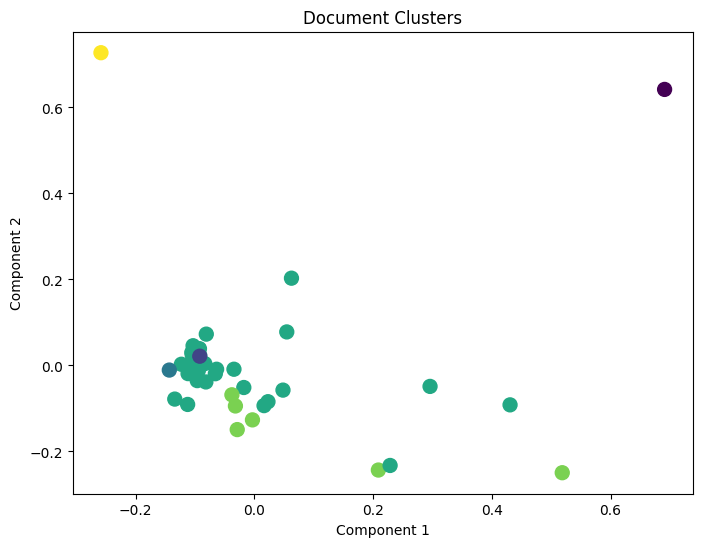

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(x_2d[:, 0], x_2d[:, 1], c=labels, cmap="viridis", s=100)

plt.title("Document Clusters")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.show()

## Retrieval Example

We will convert a query to vector and then we will run similarity on each.

In [110]:
# query= "neural networks deep learns learning techniques natural language processing"
query = "portfolio diversification risk management strategies"
q_tokens = query.split()

q_vector = [0] * len(vocab)
for token in q_tokens:
    if token in mapper:
        index = mapper[token]
        q_vector[index] = doc_frequency[token][0]  # idf score


for index, vector in enumerate(vectors.values()):
    similarity = cosine_similarity(q_vector, vector)
    if similarity > 0.4:
        print(documents[index])
        print(f"Document {index} similarity: {similarity:.4f}")
        print()
    

portfolio diversification helps reduce financial risk
Document 12 similarity: 0.5776

risk management strategies protect financial institutions from losses
Document 14 similarity: 0.4478

